# Gotting knowledge about the data

The data file contains the approximate number of immigrants from all countries who went to Canada from 1980 to 2013. Furthermore, it includes additional information about the location of each country, illustrating the continent in which it is located and whether the region is developing or already developed.

In [1]:
# Reading the data:
import pandas as pd
import matplotlib as mpl

In [2]:
original_dataframe = pd.read_csv('../data/imigrantes_canada.csv')

In [3]:
# Visualizating the dataset
original_dataframe

,País,Continente,Região,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afeganistão,Ásia,Sul da Ásia,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albânia,Europa,Sul da Europa,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
2,Argélia,África,Norte da África,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,Samoa Americana,Oceânia,Polinésia,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europa,Sul da Europa,0,0,0,0,0,0,2,...,0,1,1,0,0,0,0,1,1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Vietnã,Ásia,Sudeste Asiático,1191,1829,2162,3404,7583,5907,2741,...,1852,3153,2574,1784,2171,1942,1723,1731,2112,97146
191,Saara Ocidental,África,Norte da África,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,2
192,Iémen,Ásia,Ásia Ocidental,1,2,1,6,0,18,7,...,161,140,122,133,128,211,160,174,217,2985
193,Zâmbia,África,África Oriental,11,17,11,7,16,9,15,...,91,77,71,64,60,102,69,46,59,1677


In [4]:
# The infos about the dataset:
original_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 38 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   País        195 non-null    str  
 1   Continente  195 non-null    str  
 2   Região      195 non-null    str  
 3   1980        195 non-null    int64
 4   1981        195 non-null    int64
 5   1982        195 non-null    int64
 6   1983        195 non-null    int64
 7   1984        195 non-null    int64
 8   1985        195 non-null    int64
 9   1986        195 non-null    int64
 10  1987        195 non-null    int64
 11  1988        195 non-null    int64
 12  1989        195 non-null    int64
 13  1990        195 non-null    int64
 14  1991        195 non-null    int64
 15  1992        195 non-null    int64
 16  1993        195 non-null    int64
 17  1994        195 non-null    int64
 18  1995        195 non-null    int64
 19  1996        195 non-null    int64
 20  1997        195 non-null    int64
 21  1998

Since there are no null data points, and we are not preparing a database to train a machine learning model, there is no need to process the dataset.

### Analisy the Brazil to Canada imigration trends by the years

In [5]:
# Verifying if there is a duplicated rows before to make the countrys be the indexes
original_dataframe.duplicated().sum()

np.int64(0)

In [6]:
dataframe = original_dataframe

In [7]:
dataframe.set_index('País', inplace=True)

In [8]:
dataframe

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Afeganistão,Ásia,Sul da Ásia,16,39,39,47,71,340,496,741,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albânia,Europa,Sul da Europa,1,0,0,0,0,0,1,2,...,1223,856,702,560,716,561,539,620,603,15699
Argélia,África,Norte da África,80,67,71,69,63,44,69,132,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
Samoa Americana,Oceânia,Polinésia,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,6
Andorra,Europa,Sul da Europa,0,0,0,0,0,0,2,0,...,0,1,1,0,0,0,0,1,1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vietnã,Ásia,Sudeste Asiático,1191,1829,2162,3404,7583,5907,2741,1406,...,1852,3153,2574,1784,2171,1942,1723,1731,2112,97146
Saara Ocidental,África,Norte da África,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,2
Iémen,Ásia,Ásia Ocidental,1,2,1,6,0,18,7,12,...,161,140,122,133,128,211,160,174,217,2985


In [9]:
# Creating a list with year intervals
years = list(map(str, range(1980, 2014)))

In [10]:
years

['1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013']

In [11]:
my_years = dataframe.columns[2:-1]

my_years

Index(['1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988',
       '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997',
       '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013'],
      dtype='str')

In [12]:
brazil = dataframe.loc['Brasil', my_years]

In [13]:
brazil

1980     211
1981     220
1982     192
1983     139
1984     145
1985     130
1986     205
1987     244
1988     394
1989     650
1990     650
1991     877
1992    1066
1993     866
1994     566
1995     572
1996     586
1997     591
1998     531
1999     626
2000     845
2001     847
2002     745
2003     839
2004     917
2005     969
2006    1181
2007    1746
2008    2138
2009    2509
2010    2598
2011    1508
2012    1642
2013    1714
Name: Brasil, dtype: int64

In [14]:
new_df_brazil_data = {
    'ano': list(brazil.index),
    'amount_of_imigrates': list(brazil.values)
}

brazil_data_dataframe = pd.DataFrame(new_df_brazil_data)

In [15]:
# Imigrants from Brazil to Canada for each year since 1980 to 2013
brazil_data_dataframe

,ano,amount_of_imigrates
0,1980,211
1,1981,220
2,1982,192
3,1983,139
4,1984,145
5,1985,130
6,1986,205
7,1987,244
8,1988,394
9,1989,650


### Creating the graphic about the amount of imigrants that moved from Brasil to Canada.

In [16]:
# Fot it, we'll use the pyplot from matplotlib:
import matplotlib.pyplot as plt

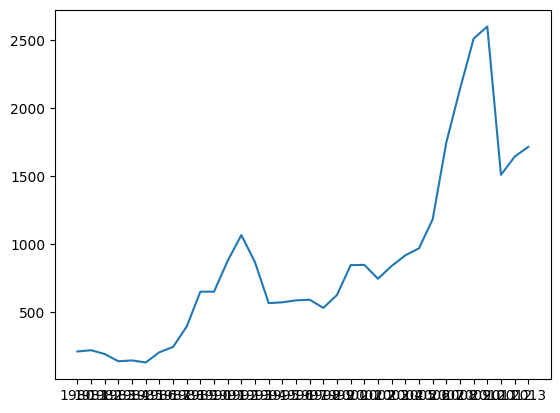

In [17]:
plt.plot(brazil_data_dataframe['ano'], brazil_data_dataframe['amount_of_imigrates'])

In [18]:
# Let's plot a graph showing the number of immigrants who went to Canada every 5 years. Then:
five_to_five_years = [my_years[i] for i in range(0, len(my_years) + 1, 5)]

# debugging
print(five_to_five_years)

['1980', '1985', '1990', '1995', '2000', '2005', '2010']


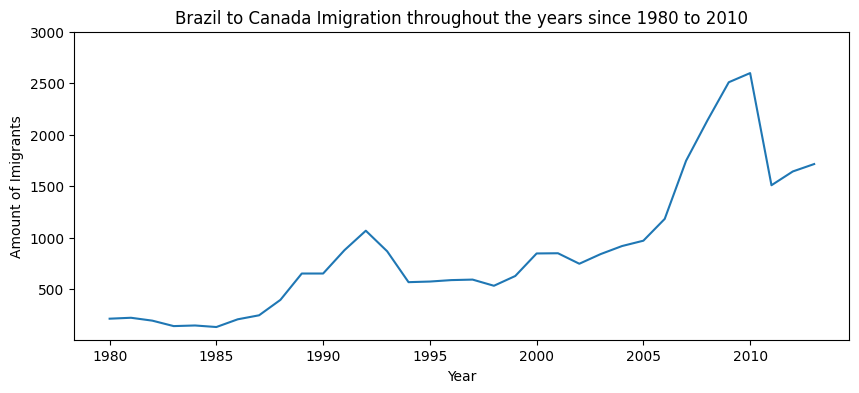

In [19]:
plt.figure(figsize=(10, 4))

plt.plot(brazil_data_dataframe['ano'], brazil_data_dataframe['amount_of_imigrates'])
# adding the title and labels 
plt.title('Brazil to Canada Imigration throughout the years since 1980 to 2010')

# The labels:
plt.xlabel('Year')
plt.ylabel('Amount of Imigrants')

# x-axis markings -> xticks()
plt.xticks(five_to_five_years)
plt.yticks([500, 1000, 1500, 2000, 2500, 3000])

# Removing the plot information, leaving only the graphic visible.
plt.show() # this interrupt the code to run, so put it on the last line

# Creating a figure to further customize the chart.

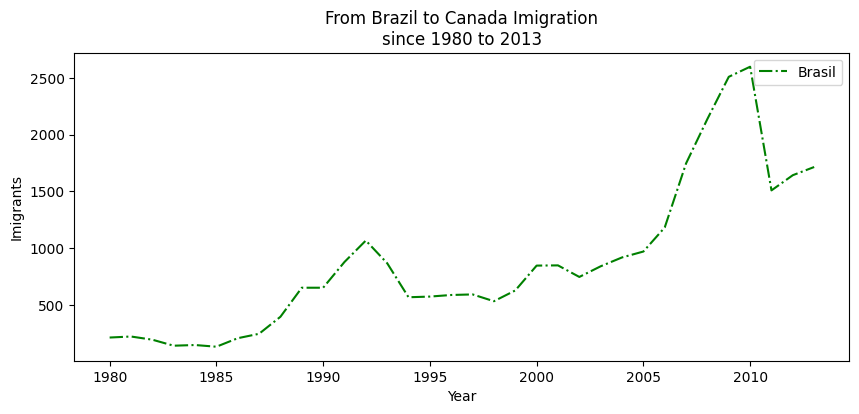

In [20]:
# Creating figures with subplots:
fig, ax = plt.subplots(figsize=(10, 4)) # fig é a figura que será criada e ax será os eixos da figura.

ax.plot(brazil_data_dataframe['ano'], brazil_data_dataframe['amount_of_imigrates'], 'g-.' , label='Brasil')

# Adding a title for the chart:
ax.set_title('From Brazil to Canada Imigration\nsince 1980 to 2013')

ax.set_xlabel('Year')
ax.set_ylabel('Imigrants')

ax.legend()

ax.xaxis.set_major_locator(plt.MultipleLocator(5)) # like the plt.xticks() with the list of years on 5 years frequency

plt.show()


### Add a boxplot chart to analisy the statistics informations

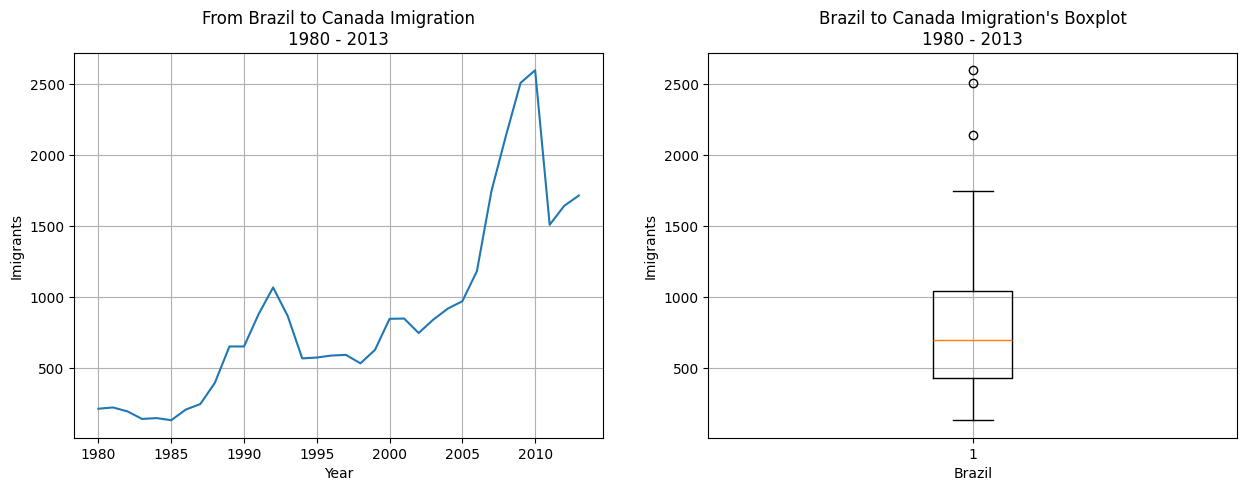

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# First Chart:
axs[0].plot(brazil_data_dataframe['ano'], brazil_data_dataframe['amount_of_imigrates'], label='Brazilian imigrants')

axs[0].set_title('From Brazil to Canada Imigration\n1980 - 2013')
axs[0].set_xlabel('Year')
axs[0].set_ylabel('Imigrants')
axs[0].xaxis.set_major_locator(plt.MultipleLocator(5))
axs[0].grid()

# Second Chart:
axs[1].boxplot(brazil_data_dataframe['amount_of_imigrates'])
axs[1].set_title("Brazil to Canada Imigration's Boxplot\n1980 - 2013")
axs[1].set_xlabel('Brazil')
axs[1].set_ylabel('Imigrants')
axs[1].grid()

plt.show()


In [22]:
brazil_data_dataframe.describe()

,amount_of_imigrates
count,34.000000
mean,872.323529
std,663.401232
min,130.000000
25%,428.250000
50%,697.500000
75%,1041.750000
max,2598.000000


### Making the same analisy for the biggers countrys of South America

In [23]:
print(f'{type(my_years)}\n{my_years}')

<class 'pandas.Index'>
Index(['1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988',
       '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997',
       '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013'],
      dtype='str')


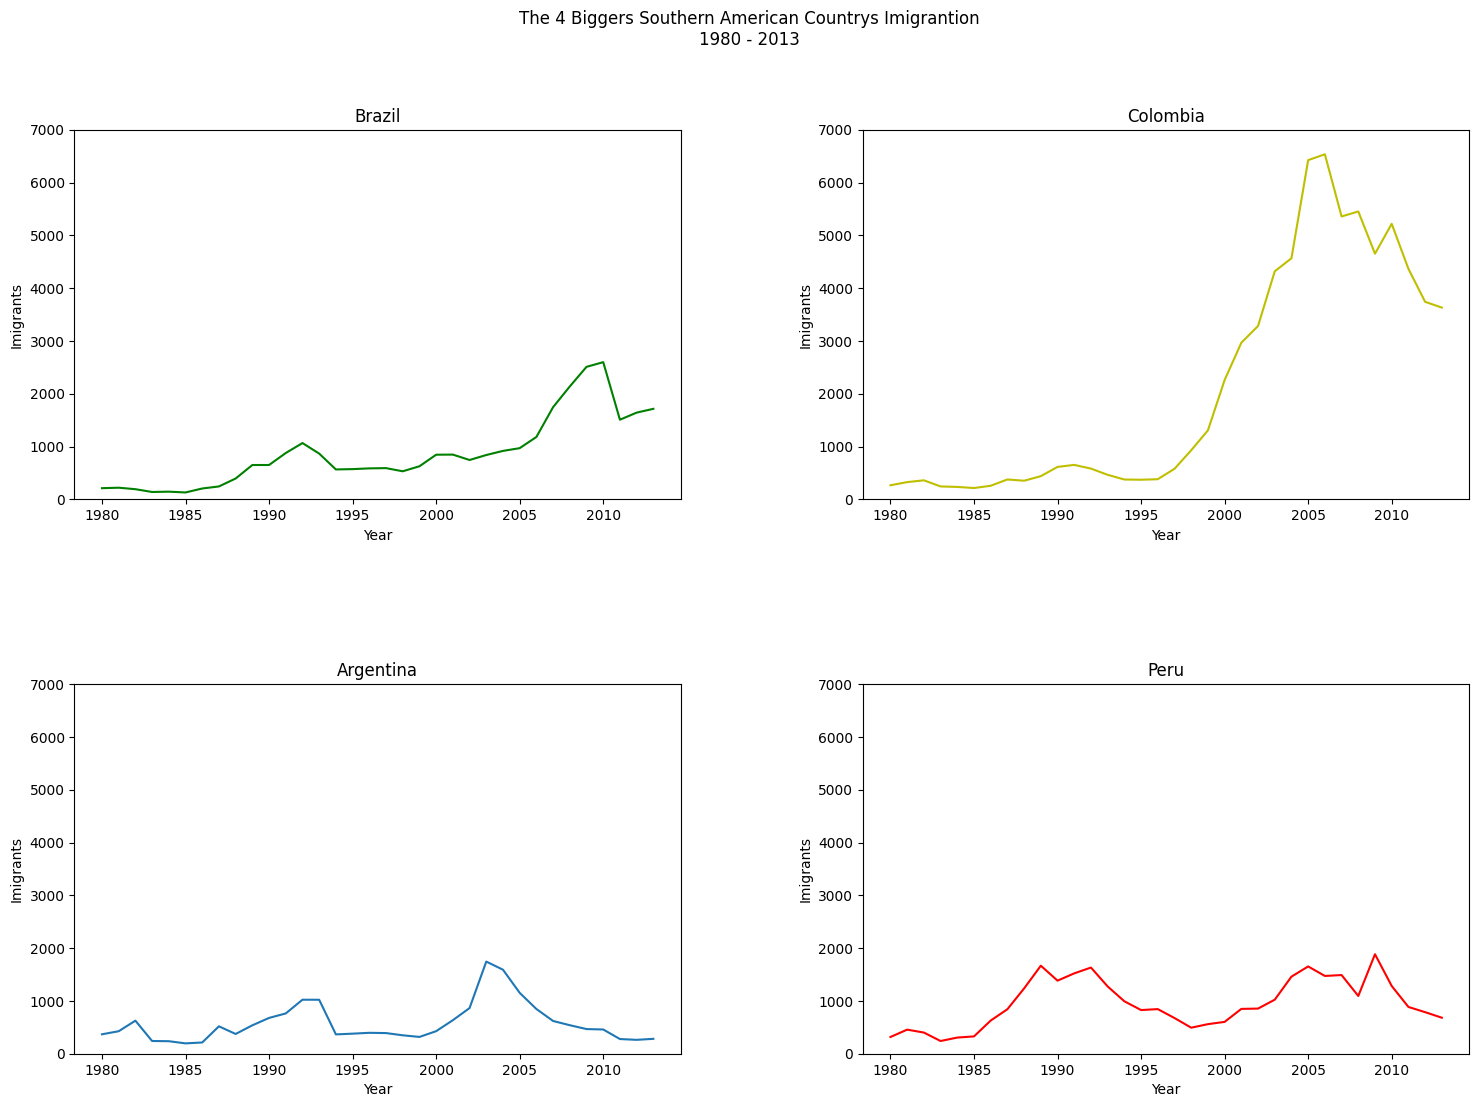

In [24]:
# The countrys is: Brasil, Argentina, Colombia e Peru

# Creating the figure of the subplots:
fig, axs = plt.subplots(2, 2, figsize=(18, 12))

fig.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle('The 4 Biggers Southern American Countrys Imigrantion\n1980 - 2013')

# Brazil
axs[0, 0].plot(dataframe.loc['Brasil', list(my_years)], 'g')
axs[0, 0].set_title('Brazil')

# Colombia
axs[0, 1].plot(dataframe.loc['Colômbia', list(my_years)], 'y')
axs[0, 1].set_title('Colombia')

# Argentina
axs[1, 0].plot(dataframe.loc['Argentina', list(my_years)])
axs[1, 0].set_title('Argentina')

# Peru
axs[1, 1].plot(dataframe.loc['Peru', list(my_years)], 'r')
axs[1, 1].set_title('Peru')

ymin = 0
ymax = 7000

# For everyone:
for ax in axs.flat:
    ax.xaxis.set_major_locator(plt.MultipleLocator(5))
    ax.set_xlabel('Year')
    ax.set_ylabel('Imigrants')

for ax in axs.ravel():
    ax.set_ylim(ymin=ymin, ymax=ymax)

plt.show()


# Futher costumize the chart

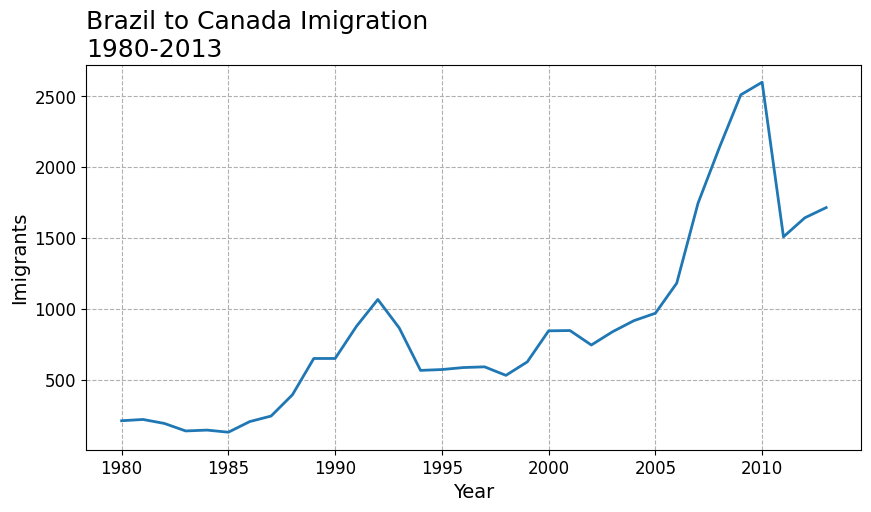

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(brazil_data_dataframe['ano'], brazil_data_dataframe['amount_of_imigrates'], lw=2)

ax.set_title('Brazil to Canada Imigration\n1980-2013', fontsize=18, loc='left') # Modify the size of the title and the text position with the loc param

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Imigrants', fontsize=14)

ax.xaxis.set_tick_params(labelsize=12)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))

ax.yaxis.set_tick_params(labelsize=12)

ax.grid(linestyle='--')

plt.show()

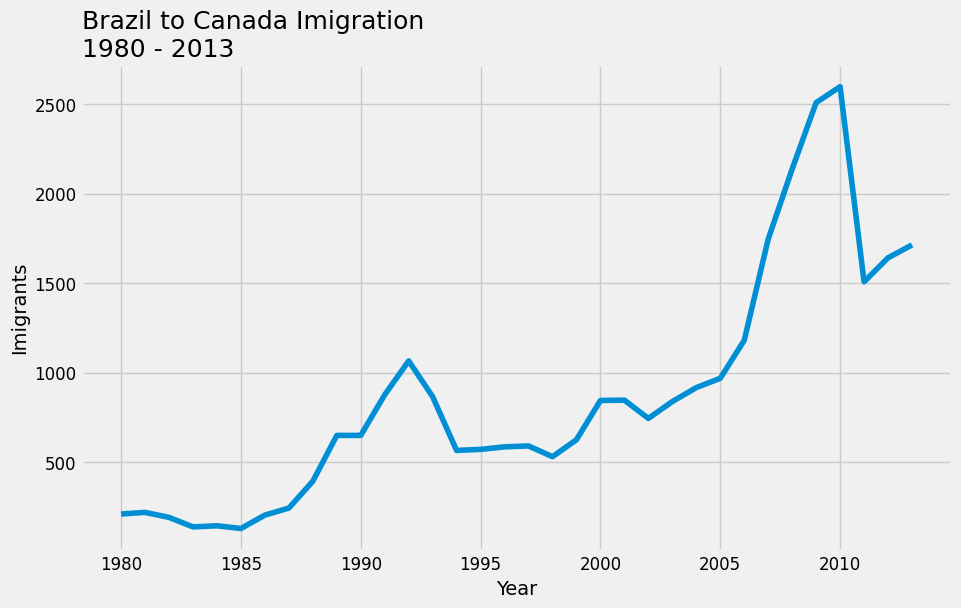

In [26]:
with plt.style.context('fivethirtyeight'):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(brazil_data_dataframe['ano'], brazil_data_dataframe['amount_of_imigrates'])

    ax.set_title('Brazil to Canada Imigration\n1980 - 2013', fontsize=18, loc='left')

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('Imigrants', fontsize=14)

    ax.yaxis.set_tick_params(labelsize=12)
    ax.xaxis.set_tick_params(labelsize=12)
    ax.xaxis.set_major_locator(plt.MultipleLocator(5))

    plt.show()

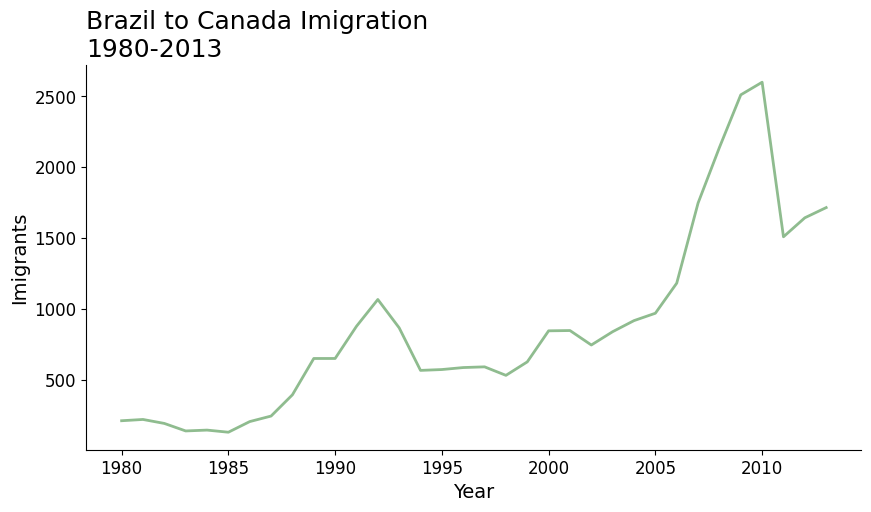

In [27]:
# Change the colors of the chart
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(brazil_data_dataframe['ano'], brazil_data_dataframe['amount_of_imigrates'], lw=2, color='darkseagreen')

ax.set_title('Brazil to Canada Imigration\n1980-2013', fontsize=18, loc='left') # Modify the size of the title and the text position with the loc param

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Imigrants', fontsize=14)

ax.xaxis.set_tick_params(labelsize=12)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))

ax.yaxis.set_tick_params(labelsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ax.grid(linestyle='--')

fig.savefig('brazil_to_canada_imigration.png', transparent=False, dpi=300, bbox_inches='tight')

plt.show()

In [28]:
dataframe.head()

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Afeganistão,Ásia,Sul da Ásia,16,39,39,47,71,340,496,741,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albânia,Europa,Sul da Europa,1,0,0,0,0,0,1,2,...,1223,856,702,560,716,561,539,620,603,15699
Argélia,África,Norte da África,80,67,71,69,63,44,69,132,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
Samoa Americana,Oceânia,Polinésia,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,6
Andorra,Europa,Sul da Europa,0,0,0,0,0,0,2,0,...,0,1,1,0,0,0,0,1,1,15


In [29]:
southAmerica_df = dataframe.query('Região == "América do Sul"')

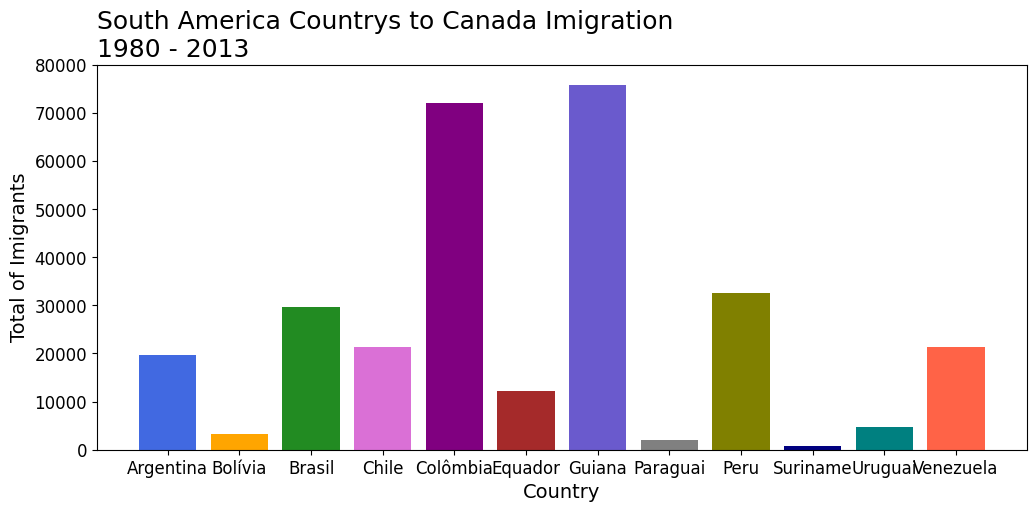

In [30]:
# Analize the total imigration of each south american country:
colors = ['royalblue', 'orange', 'forestgreen', 'orchid', 'purple', 'brown', 'slateblue', 'gray', 'olive', 'navy', 'teal', 'tomato']

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(list(southAmerica_df.index), southAmerica_df['Total'], color=colors)

ax.set_title('South America Countrys to Canada Imigration\n1980 - 2013', loc='left', fontsize=18)

ax.set_xlabel('Country', fontsize=14)
ax.set_ylabel('Total of Imigrants', fontsize=14)

ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)

ax.set_ylim(ymin=0, ymax=80000)

plt.show()

In [31]:
# Sort the values of total of imigrants:
southAmerica_total_series = southAmerica_df.loc[:, 'Total']

southAmerica_total_series.sort_values(ascending=True, inplace=True)

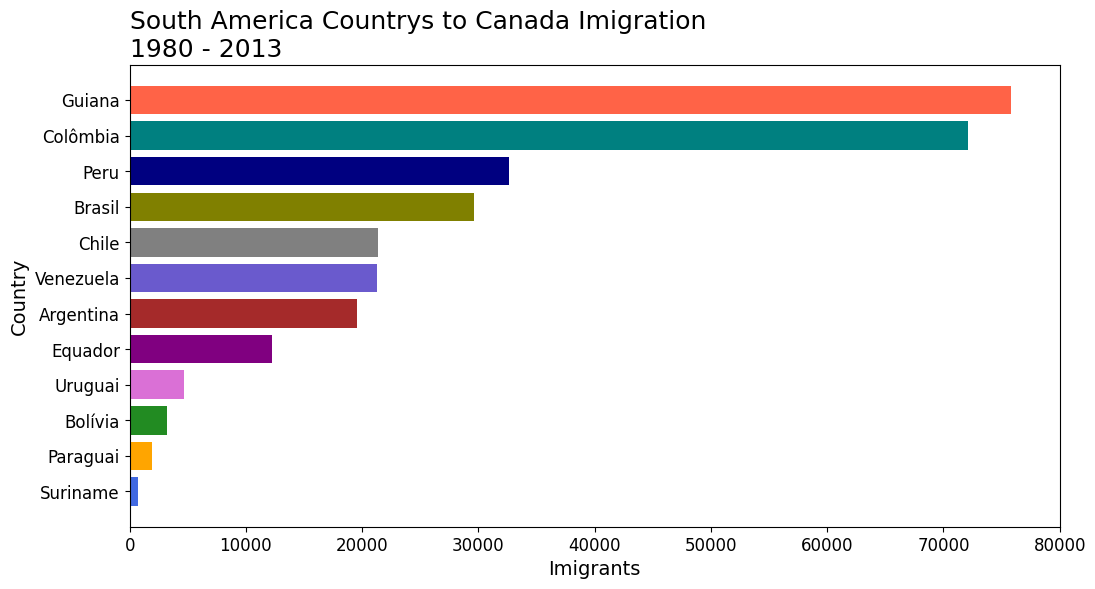

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(list(southAmerica_total_series.index), list(southAmerica_total_series.values), color=colors)

ax.set_title('South America Countrys to Canada Imigration\n1980 - 2013', loc='left', fontsize=18)

ax.set_xlabel('Imigrants', fontsize=14)
ax.set_ylabel('Country', fontsize=14)

ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

ax.set_xlim(xmin=0, xmax=80000)

plt.show()

In [33]:
colors = ['green' if pais == 'Brasil' else 'silver' for pais in southAmerica_total_series.index]

print(colors)

['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'green', 'silver', 'silver', 'silver']


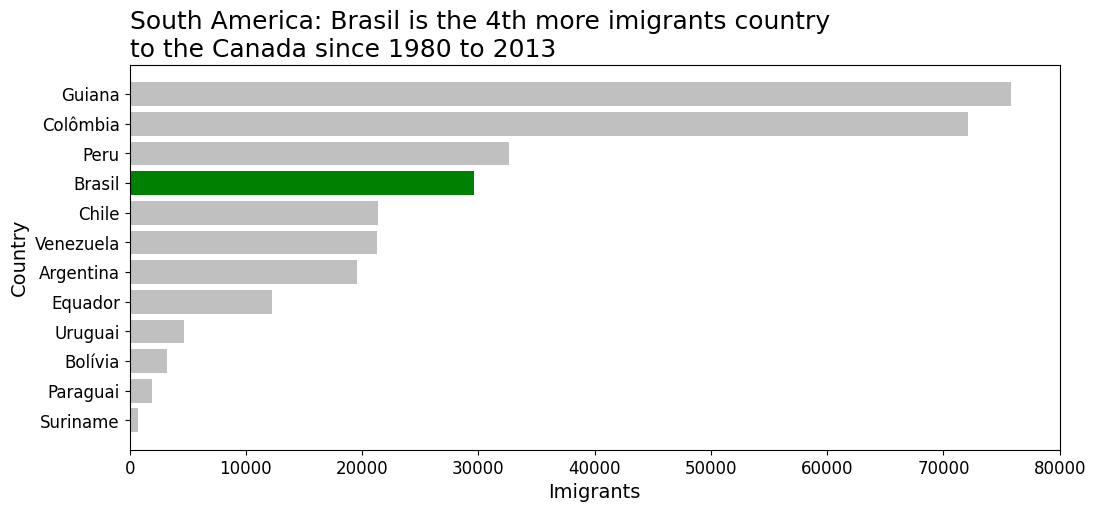

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.barh(list(southAmerica_total_series.index), list(southAmerica_total_series.values), color=colors)

ax.set_title('South America: Brasil is the 4th more imigrants country\nto the Canada since 1980 to 2013', loc='left', fontsize=18)

ax.set_xlabel('Imigrants', fontsize=14)
ax.set_ylabel('Country', fontsize=14)

ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

ax.set_xlim(xmin=0, xmax=80000)

plt.show()


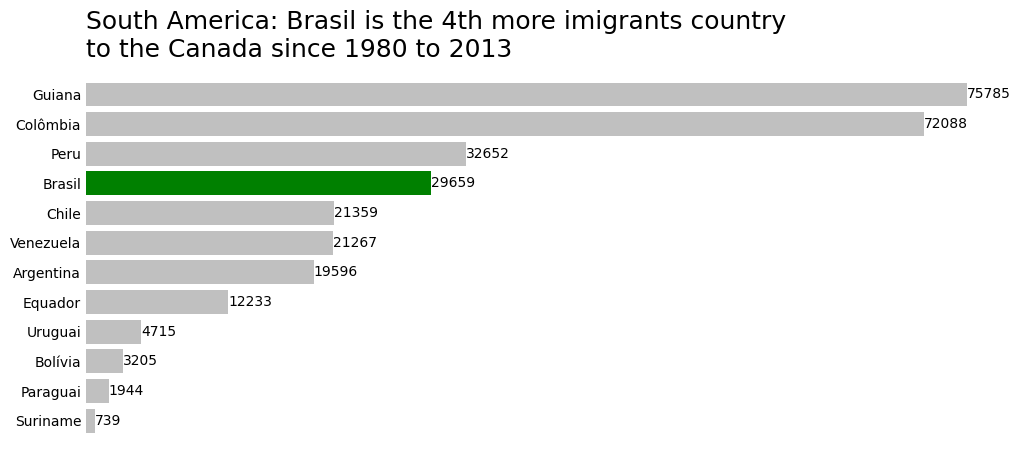

In [35]:
# Adding anotations to the figure:
fig, ax = plt.subplots(figsize=(12, 5))

ax.barh(list(southAmerica_total_series.index), list(southAmerica_total_series.values), color=colors)

ax.set_title('South America: Brasil is the 4th more imigrants country\nto the Canada since 1980 to 2013', loc='left', fontsize=18)

ax.set_xlim(xmin=0, xmax=80000)

for i, v in enumerate(southAmerica_total_series.values):
    ax.text(v, i, str(v), color='black', fontsize=10, ha='left', va='center')

ax.set_frame_on(False)
ax.get_xaxis().set_visible(False)
ax.tick_params(axis='both', which='both', length=0)

fig.savefig('south_america_imigration.png', transparent=False, dpi=400, bbox_inches='tight')

plt.show()


In [36]:
# Saving charts with the matplotlib:
print(fig.canvas.get_supported_filetypes())

{'eps': 'Encapsulated Postscript', 'jpg': 'Joint Photographic Experts Group', 'jpeg': 'Joint Photographic Experts Group', 'pdf': 'Portable Document Format', 'pgf': 'PGF code for LaTeX', 'png': 'Portable Network Graphics', 'ps': 'Postscript', 'raw': 'Raw RGBA bitmap', 'rgba': 'Raw RGBA bitmap', 'svg': 'Scalable Vector Graphics', 'svgz': 'Scalable Vector Graphics', 'tif': 'Tagged Image File Format', 'tiff': 'Tagged Image File Format', 'webp': 'WebP Image Format'}


# Another lib to plot charts: Seaborn

In [37]:
import seaborn as sns

In [38]:
# Define de default theme of the charts:
sns.set_theme() # every chart that we create after this line will have the default theme of seaborn, but we can change it with the sns.set_style() function.

In [39]:
sns.set_style()

In [40]:
top_ten_countrys_imigrants = dataframe.sort_values(by='Total', ascending=False).head(10)

In [41]:
top_ten_countrys_imigrants

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Índia,Ásia,Sul da Ásia,8880,8670,8147,7338,5704,4211,7150,10189,...,36210,33848,28742,28261,29456,34235,27509,30933,33087,691904
China,Ásia,Ásia Oriental,5123,6682,3308,1863,1527,1816,1960,2643,...,42584,33518,27642,30037,29622,30391,28502,33024,34129,659962
Reino Unido e Irlanda do Norte,Europa,Norte da Europa,22045,24796,20620,10015,10170,9564,9470,21337,...,7258,7140,8216,8979,8876,8724,6204,6195,5827,551500
Filipinas,Ásia,Sudeste Asiático,6051,5921,5249,4562,3801,3150,4166,7360,...,18139,18400,19837,24887,28573,38617,36765,34315,29544,511391
Paquistão,Ásia,Sul da Ásia,978,972,1201,900,668,514,691,1072,...,14314,13127,10124,8994,7217,6811,7468,11227,12603,241600
Estados Unidos da América,América do Norte,América do Norte,9378,10030,9074,7100,6661,6543,7074,7705,...,8394,9613,9463,10190,8995,8142,7676,7891,8501,241122
Irã,Ásia,Sul da Ásia,1172,1429,1822,1592,1977,1648,1794,2989,...,5837,7480,6974,6475,6580,7477,7479,7534,11291,175923
Sri Lanka,Ásia,Sul da Ásia,185,371,290,197,1086,845,1838,4447,...,4930,4714,4123,4756,4547,4422,3309,3338,2394,148358
República da Coreia,Ásia,Ásia Oriental,1011,1456,1572,1081,847,962,1208,2338,...,5832,6215,5920,7294,5874,5537,4588,5316,4509,142581


<Axes: xlabel='País', ylabel='Total'>

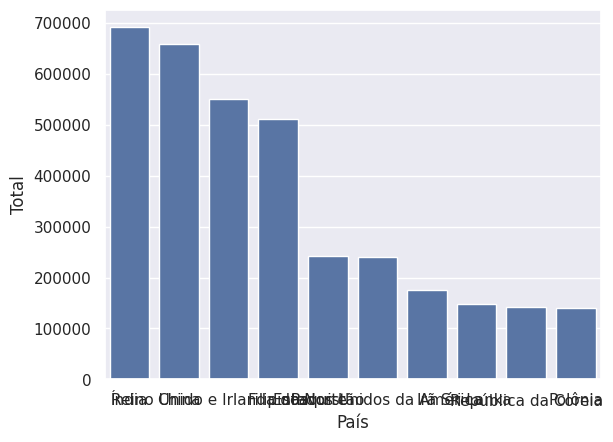

In [42]:
sns.barplot(data=top_ten_countrys_imigrants, x='País', y='Total')

<Axes: xlabel='Total', ylabel='País'>

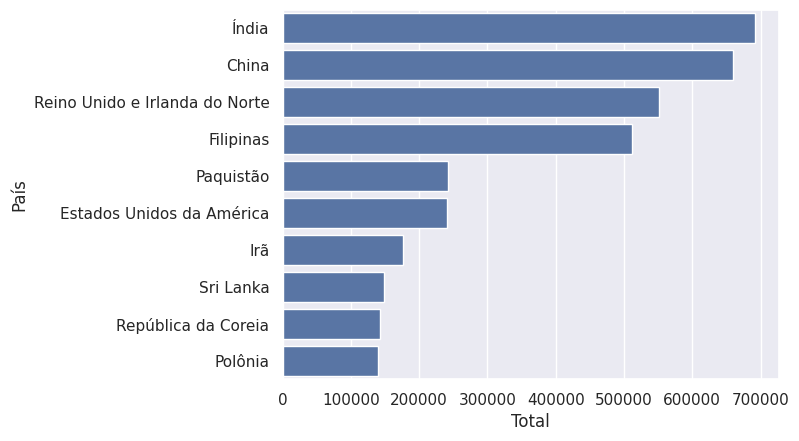

In [43]:
sns.barplot(data=top_ten_countrys_imigrants, x='Total', y=top_ten_countrys_imigrants.index, orient='h')

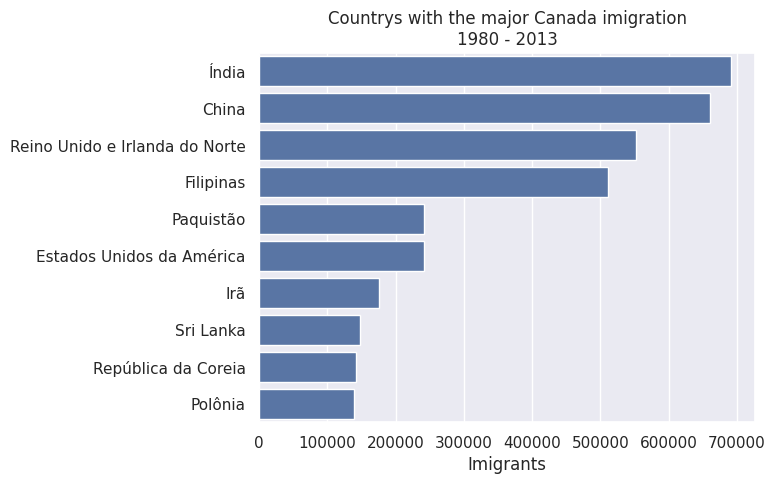

In [44]:
# Personaling the charts with seaborn:
ax = sns.barplot(data=top_ten_countrys_imigrants, x='Total', y=top_ten_countrys_imigrants.index, orient='h')

ax.set(title='Countrys with the major Canada imigration\n1980 - 2013',
       xlabel='Imigrants',
       ylabel='')

plt.show()

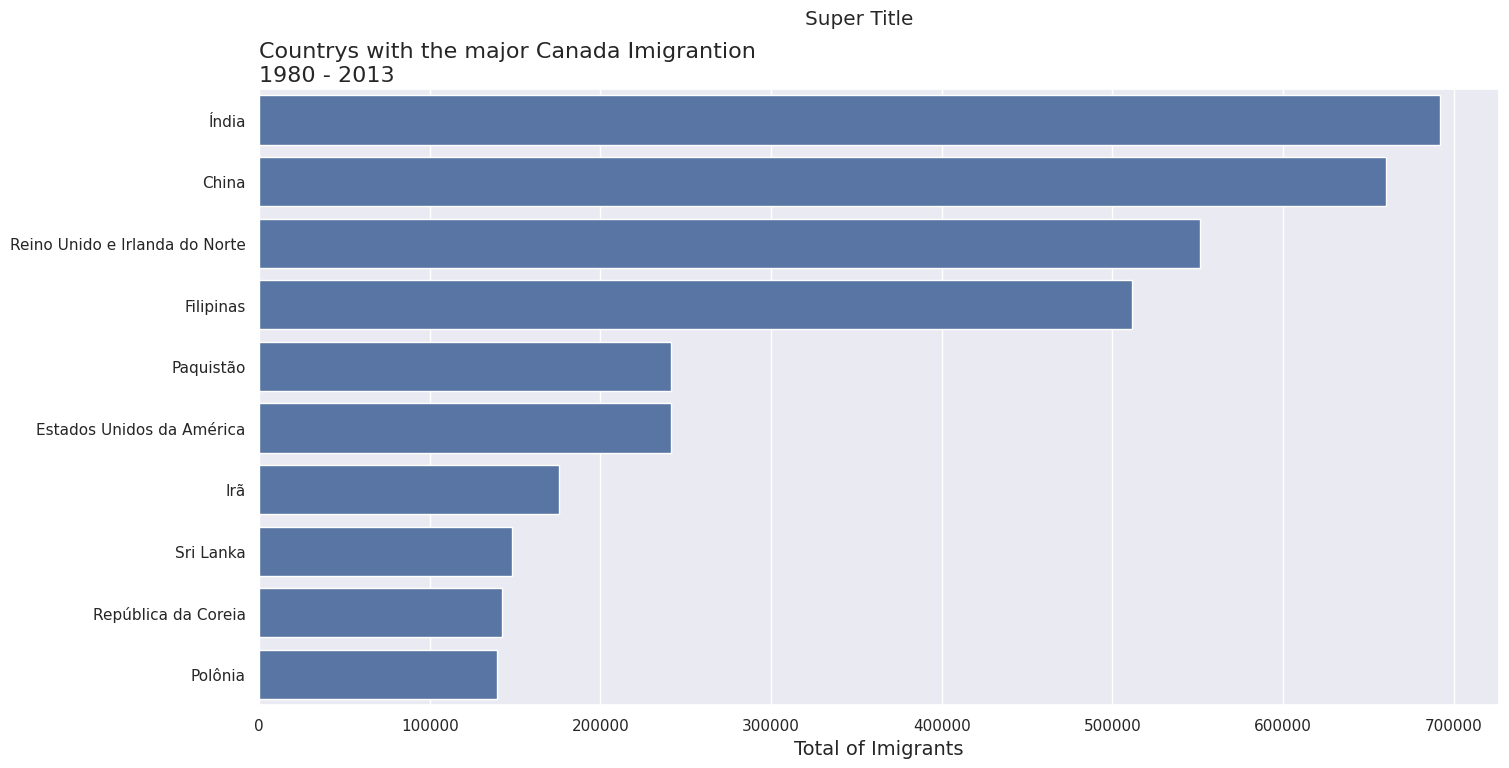

In [45]:
fig, ax = plt.subplots(figsize=(16, 8))

fig.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle('Super Title')

ax = sns.barplot(data=top_ten_countrys_imigrants, x='Total', y=top_ten_countrys_imigrants.index, orient='h')

ax.set_title('Countrys with the major Canada Imigrantion\n1980 - 2013', fontsize=16, loc='left')
ax.set_xlabel('Total of Imigrants', fontsize=14)
ax.set_ylabel('')

plt.show()

In [ ]:
# Adding colors for our chart:
def gen_color_palette(palette: str):
    fig, ax = plt.subplots(figsize=(8, 4))

    ax = sns.barplot(data=top_ten_countrys_imigrants, x='Total', y=top_ten_countrys_imigrants.index, orient='h', palette=palette, hue=top_ten_countrys_imigrants.index, legend=False)

    ax.set_title('Countrys with the major Canada Imigrantion\n1980 - 2013', loc='left', fontsize=18)
    ax.set_xlabel('Total of Imigrants')
    ax.set_ylabel('')

    plt.show()

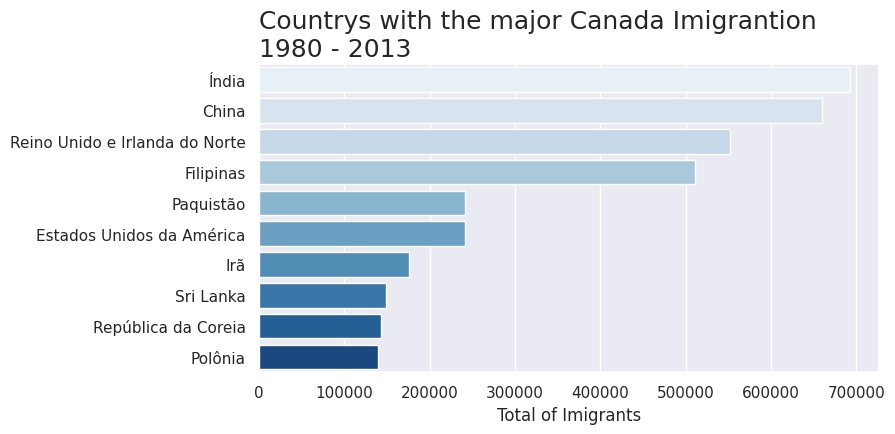

In [62]:
gen_color_palette('Blues')

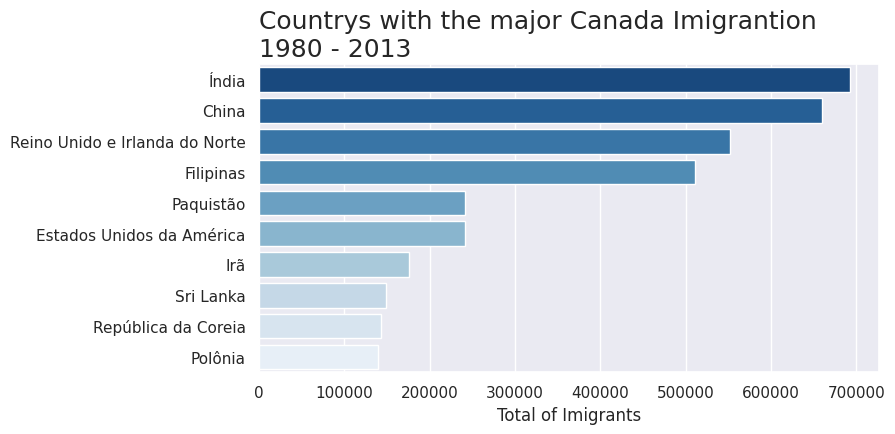

In [63]:
gen_color_palette('Blues_r')

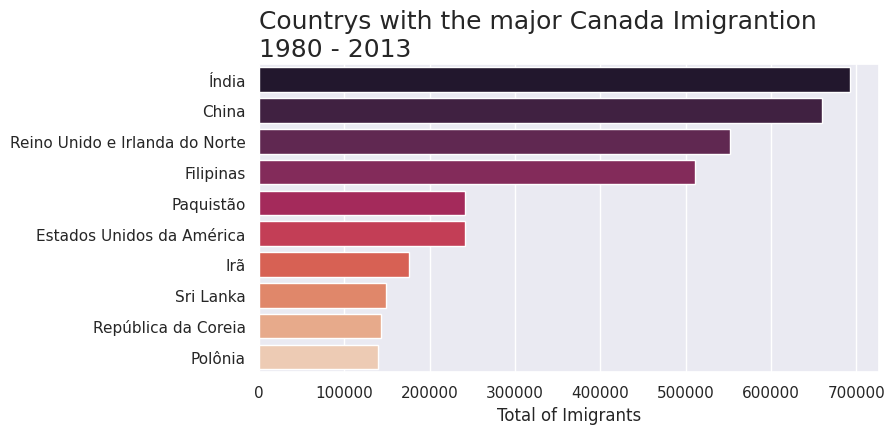

In [64]:
gen_color_palette('rocket')

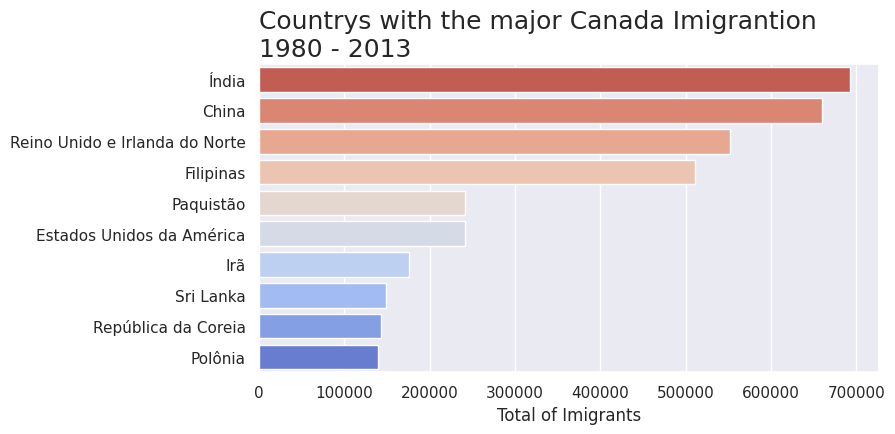

In [65]:
gen_color_palette('coolwarm_r')

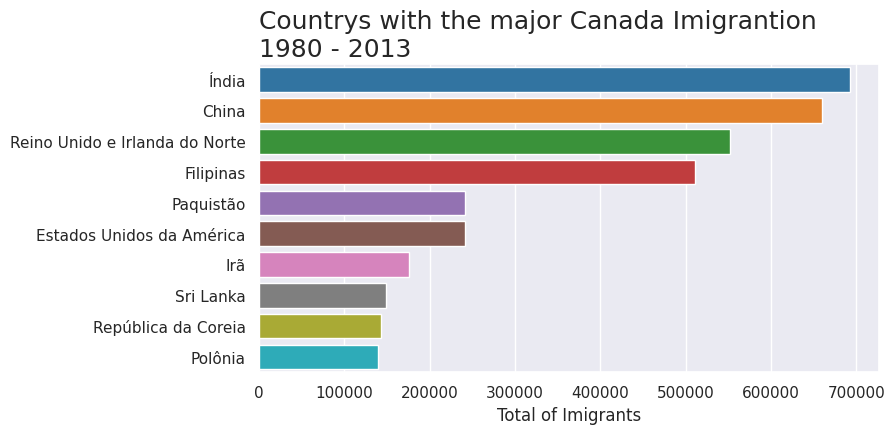

In [66]:
gen_color_palette('tab10') # categorical palette

### Explore themes from the Seaborn Library

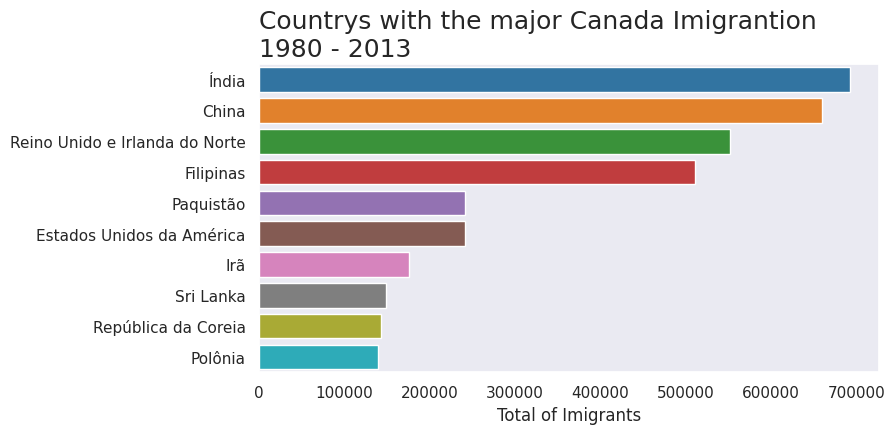

In [68]:
sns.set_theme(style='dark')

gen_color_palette(palette='tab10')

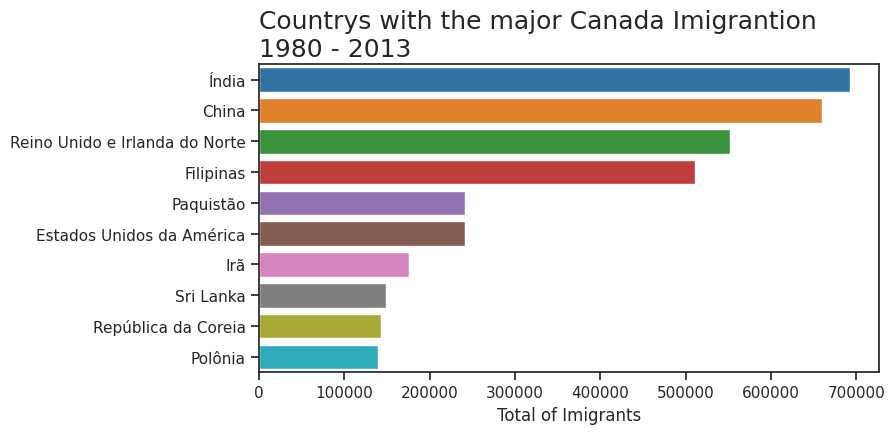

In [74]:
sns.set_theme(style='ticks')

gen_color_palette(palette='tab10')

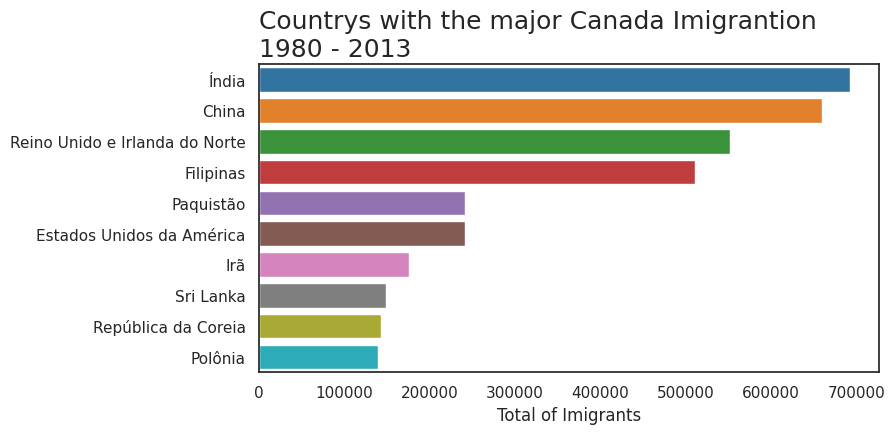

In [ ]:
sns.set_theme(style='white')
gen_color_palette(palette='tab10')

/tmp/ipykernel_4930/249965606.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_ten_countrys_imigrants, x='Total', y=top_ten_countrys_imigrants.index, orient='h', palette='tab10')


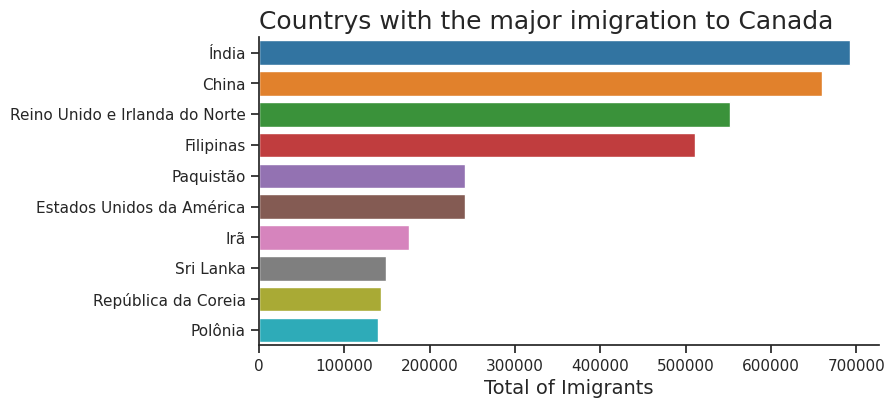

In [75]:
sns.set_theme(style='ticks')

fig, ax = plt.subplots(figsize=(8, 4))

ax = sns.barplot(data=top_ten_countrys_imigrants, x='Total', y=top_ten_countrys_imigrants.index, orient='h', palette='tab10')

ax.set_title('Countrys with the major imigration to Canada', loc='left', fontsize=18)

ax.set_xlabel('Total of Imigrants', fontsize=14)
ax.set_ylabel('')

sns.despine()

plt.show()
